In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchvision.models as models
import wandb

In [3]:
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=3):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1_2 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2_2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3_2 = nn.BatchNorm2d(128)

        self.dropout2d = nn.Dropout2d(p=0.2)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # self.pool = nn.AvgPool2d(kernel_size=2, stride=2)    

        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(p=0.4)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv1_2(x)
        x = self.bn1_2(x)
        x = F.relu(x)
        x = self.pool(x)


        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv2_2(x)
        x = self.bn2_2(x)
        x = F.relu(x)
        x = self.pool(x)


        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout2d(x)

        x = self.conv3_2(x)
        x = self.bn3_2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.reshape(x.shape[0], -1) 

        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('L')
        
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
            
        return image, label

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

data_dir = Path('Breast-Cancer-Dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]
label_map = {name: i for i, name in enumerate(classes)}
num_classes = len(classes)

print(f"Clases encontradas: {label_map}")

file_paths = []
labels = []
for class_name, label_idx in label_map.items():
    class_dir = data_dir / class_name
    for img_path in class_dir.glob('*.[jp][pn]g'): 
        file_paths.append(str(img_path))
        labels.append(label_idx)

print(f"Total de imágenes encontradas: {len(file_paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_dataset = ImageDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_paths, val_labels, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imágenes de entreno: {len(train_dataset)}")
print(f"Imágenes de validación: {len(val_dataset)}")


Clases encontradas: {'benign': 0, 'malignant': 1, 'normal': 2}
Total de imágenes encontradas: 780
Imágenes de entreno: 624
Imágenes de validación: 156


In [ ]:
# ====================== CONFIGURACIÓN WANDB E HIPERPARÁMETROS ======================

wandb.login(key="")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

torch.manual_seed(42)
np.random.seed(42)

wandb.init(
    project="breast-cancer-cnn",
    name="modelo-base-v1",
    config={
        "architecture": "CNN-Custom",
        "dataset": "Breast-Cancer",
        "epochs": 50,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "weight_decay": 0.0001,
        "dropout": 0.5,
        "dropout_conv": 0.2,
        "patience": 7,
        "in_channels": 1,
        "num_classes": 3
    }
)

config = wandb.config

# ====================== MODELO Y OPTIMIZADOR ======================

model = CNN(in_channels=config.in_channels, num_classes=config.num_classes).to(device)

learning_rate = config.learning_rate
NUM_EPOCHS = config.epochs

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=config.weight_decay
)

wandb.config.update({"class_weights": class_weights.cpu().numpy().tolist()})

# ====================== ENTRENAMIENTO ======================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    # ----------- TRAIN -----------
    model.train()
    train_loss_sum = 0
    correct_train = 0
    n_train_samples = 0

    for images, labels in tqdm(train_loader, desc=f"Train {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        n_train_samples += labels.size(0)
        correct_train += (pred == labels).sum().item()

    train_loss = train_loss_sum / n_train_samples
    train_acc = 100 * correct_train / n_train_samples

    # ----------- VALIDATION -----------
    model.eval()
    val_loss_sum = 0
    correct_val = 0
    n_val_samples = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Val {epoch+1}/{NUM_EPOCHS}"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            n_val_samples += labels.size(0)
            correct_val += (pred == labels).sum().item()

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / n_val_samples
    val_acc = 100 * correct_val / n_val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


    # ----------- LOGGING -----------
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc
    })

    # ----------- EARLY STOPPING (SIN GUARDAR MODELO) -----------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        wandb.run.summary["best_val_loss"] = best_val_loss
        wandb.run.summary["best_epoch"] = epoch + 1

        print("  ✓ Mejor val_loss")
    else:
        patience_counter += 1
        print(f"  No mejora ({patience_counter}/{config.patience})")

        if patience_counter >= config.patience:
            print("\n⛔ Early stopping activado.")
            break

# ====================== EVALUACIÓN FINAL ======================

print("\nEvaluando modelo final (últimos pesos del entrenamiento)…")
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, pred = outputs.max(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ["benign", "malignant", "normal"]

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    ),
    "roc_curve": wandb.plot.roc_curve(
        all_labels, all_probs, labels=class_names
    ),
    "pr_curve": wandb.plot.pr_curve(
        all_labels, all_probs, labels=class_names
    )
})

wandb.finish()
print("Evaluación final completada.")


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Usando dispositivo: cpu


Val 1/50: 100%|██████████| 5/5 [00:10<00:00,  2.12s/it]


Epoch 1/50 | Train Loss: 1.2198 | Train Acc: 43.27% | Val Loss: 1.1489 | Val Acc: 26.92%
  ✓ Mejor val_loss


Val 2/50: 100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


...

Epoch 34/50 | Train Loss: 0.4052 | Train Acc: 81.57% | Val Loss: 0.5624 | Val Acc: 80.77%
  No mejora (6/7)


Val 35/50: 100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


Epoch 35/50 | Train Loss: 0.3712 | Train Acc: 83.17% | Val Loss: 0.5445 | Val Acc: 80.77%
  No mejora (7/7)

⛔ Early stopping activado.

Evaluando modelo final (últimos pesos del entrenamiento)…


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/accuracy,▁▁▂▂▂▃▄▄▄▄▅▅▅▆▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train/loss,█▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁
val/accuracy,▁▂▄▅▅▇▆▇▆▇▇▇▇▇█▆█▅▇▇▇▇▇▇▇██▇██▇████
val/loss,██▇▆▅▄▄▃▃▃▃▃▂▂▃▂▂▃▃▂▂▂▂▂▂▁▂▁▁▁▂▁▁▂▁
best_epoch,28
best_val_loss,0.51589
epoch,35
train/accuracy,83.17308
train/loss,0.37121
val/accuracy,80.76923


Evaluación final completada.


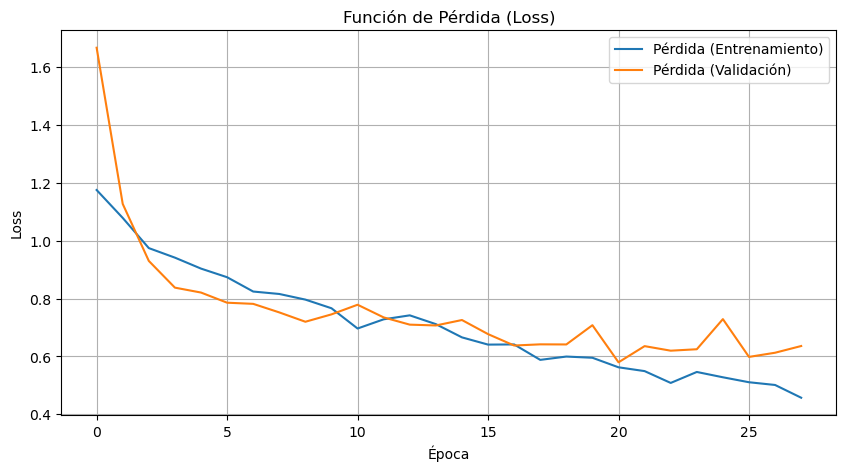

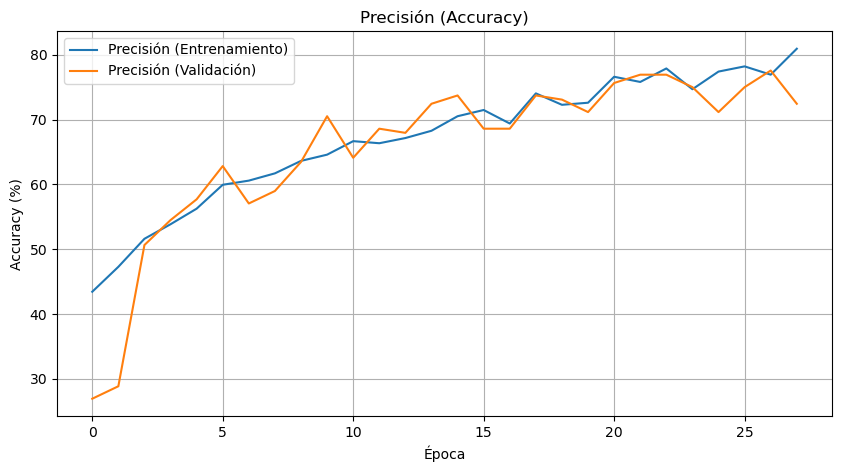

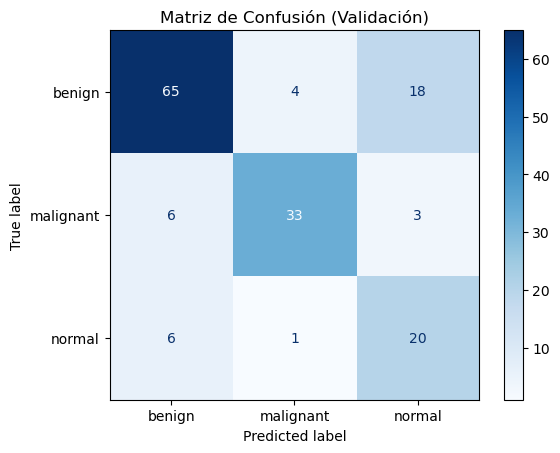

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Pérdida (Entrenamiento)')
plt.plot(history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Precisión (Entrenamiento)')
plt.plot(history['val_acc'], label='Precisión (Validación)')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Validación)')
plt.show()

In [ ]:
# ====================== CONFIGURACIÓN WANDB E HIPERPARÁMETROS ======================

wandb.login(key="")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

torch.manual_seed(42)
np.random.seed(42)

wandb.init(
    project="breast-cancer-cnn",
    name="modelo-transfer-v1",
    config={
        "architecture": "CNN-Custom",
        "dataset": "Breast-Cancer",
        "epochs": 50,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "weight_decay": 0.0001,
        "dropout": 0.5,
        "dropout_conv": 0.2,
        "patience": 7,
        "in_channels": 1,
        "num_classes": 3
    }
)

config = wandb.config

# ====================== MODELO Y OPTIMIZADOR ======================

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

model.bn1 = nn.BatchNorm2d(64)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, config.num_classes)

model = model.to(device)

print("Transfer Learning con ResNet18 configurado correctamente.")

learning_rate = config.learning_rate
NUM_EPOCHS = config.epochs

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=learning_rate,
    weight_decay=config.weight_decay
)

wandb.config.update({"class_weights": class_weights.cpu().numpy().tolist()})

# ====================== ENTRENAMIENTO ======================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    # ----------- TRAIN -----------
    model.train()
    train_loss_sum = 0
    correct_train = 0
    n_train_samples = 0

    for images, labels in tqdm(train_loader, desc=f"Train {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        n_train_samples += labels.size(0)
        correct_train += (pred == labels).sum().item()

    train_loss = train_loss_sum / n_train_samples
    train_acc = 100 * correct_train / n_train_samples

    # ----------- VALIDATION -----------
    model.eval()
    val_loss_sum = 0
    correct_val = 0
    n_val_samples = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Val {epoch+1}/{NUM_EPOCHS}"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            n_val_samples += labels.size(0)
            correct_val += (pred == labels).sum().item()

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / n_val_samples
    val_acc = 100 * correct_val / n_val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # ----------- LOGGING -----------
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc
    })

    # ----------- EARLY STOPPING (SIN GUARDAR MODELO) -----------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        wandb.run.summary["best_val_loss"] = best_val_loss
        wandb.run.summary["best_epoch"] = epoch + 1

        print("  ✓ Mejor val_loss")
    else:
        patience_counter += 1
        print(f"  No mejora ({patience_counter}/{config.patience})")

        if patience_counter >= config.patience:
            print("\n⛔ Early stopping activado.")
            break

# ====================== EVALUACIÓN FINAL ======================

print("\nEvaluando modelo final (últimos pesos del entrenamiento)…")
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, pred = outputs.max(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ["benign", "malignant", "normal"]

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    ),
    "roc_curve": wandb.plot.roc_curve(
        all_labels, all_probs, labels=class_names
    ),
    "pr_curve": wandb.plot.pr_curve(
        all_labels, all_probs, labels=class_names
    )
})

wandb.finish()
print("Evaluación final completada.")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Juan Diego\_netrc


Usando dispositivo: cpu


Transfer Learning con ResNet18 configurado correctamente.


Val 1/50: 100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


Epoch 1/50 | Train Loss: 1.0815 | Train Acc: 42.15% | Val Loss: 1.0852 | Val Acc: 38.46%
  ✓ Mejor val_loss


...

Epoch 28/50 | Train Loss: 0.8131 | Train Acc: 60.10% | Val Loss: 0.8364 | Val Acc: 50.00%
  No mejora (6/7)


Val 29/50: 100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


Epoch 29/50 | Train Loss: 0.7974 | Train Acc: 61.06% | Val Loss: 0.8806 | Val Acc: 53.21%
  No mejora (7/7)

⛔ Early stopping activado.

Evaluando modelo final (últimos pesos del entrenamiento)…


epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/accuracy,▁▁▂▄▃▄▅▅▆▅▅▆▆▆▆▇▇▆▆▆▇▇█▇█▇▇▇▇
train/loss,█▇▆▆▅▅▄▄▃▄▃▃▃▃▃▁▂▃▂▃▂▂▁▁▁▁▁▂▁
val/accuracy,▁▂▄▁▂▂▅▆▅▆▅▆▅▄█▆▆█▇▇█▇▇▇▆▇▆▄▄
val/loss,█▆▅▆▄▄▃▃▃▄▄▃▃▂▂▂▁▁▁▁▁▁▂▂▂▂▂▂▃
best_epoch,22
best_val_loss,0.76916
epoch,29
train/accuracy,61.05769
train/loss,0.79736
val/accuracy,53.20513


Evaluación final completada.


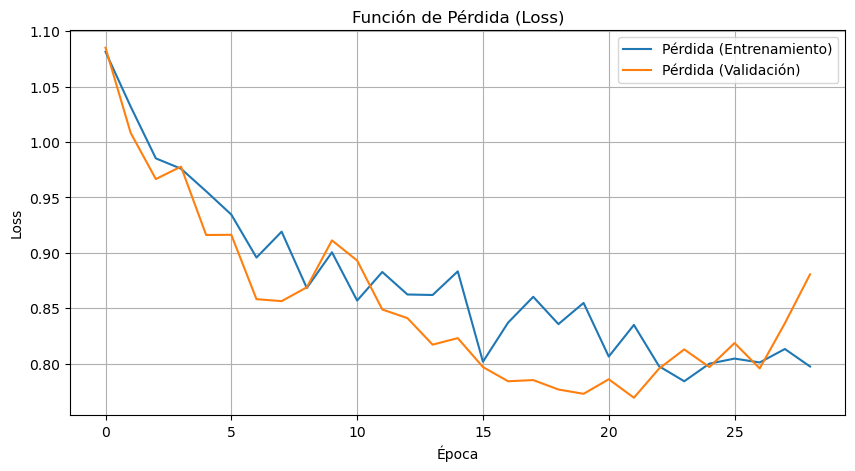

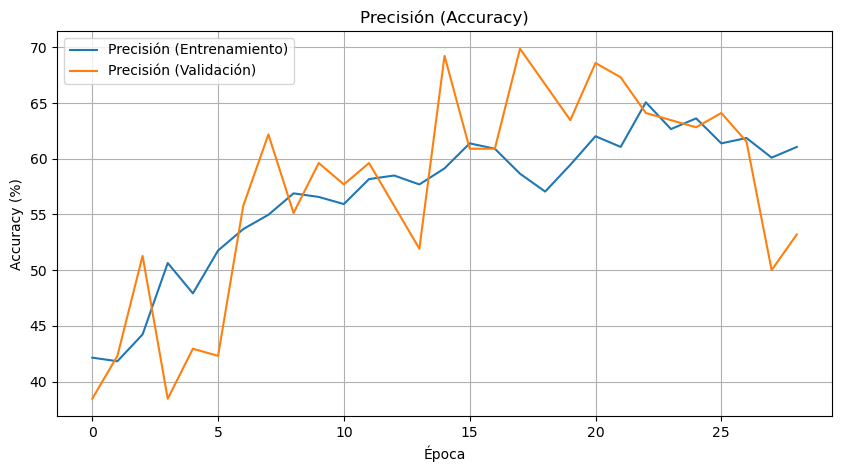

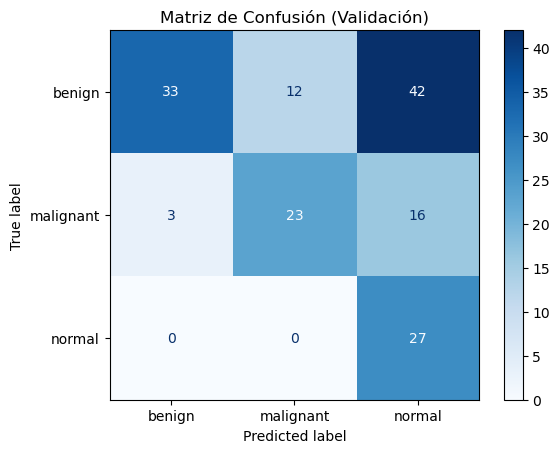

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Pérdida (Entrenamiento)')
plt.plot(history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Precisión (Entrenamiento)')
plt.plot(history['val_acc'], label='Precisión (Validación)')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Validación)')
plt.show()